# Задача №1: Интеграция Python с R через rpy2 (обмен данными)

### Задание

**Цель:** Реализовать вычисление логистической регрессии с использованием библиотеки `rpy2` для взаимодействия между Python и языком программирования R.

#### Шаги задания:

1. **Подготовка среды**
   - Установите необходимые пакеты Python (`numpy`, `rpy2`) и убедитесь, что интерпретатор R доступен на вашей машине.
   
2. **Создание входных данных**
   - Подготовьте два набора данных: матрицу признаков `X` и вектор меток классов `Y`. Используйте библиотеку `NumPy`.

3. **Преобразование данных в объекты R**
   - Передайте данные из Python в R, используя методы преобразования из библиотеки `rpy2`. Конкретнее:
     - Для матрицы признаков создайте двумерный объект типа `matrix` в R.
     - Для вектора меток — одномерный объект типа `vector`.

4. **Запуск расчета в среде R**
   - Выполните команду R, осуществляющую построение логистической регрессии. Результат должен содержать модель, доступную для дальнейшего анализа.

5. **Получение результатов**
   - Извлеките коэффициент модели (коэффициенты уравнения логистической регрессии), возвращённые R'ом, и выведите их на экран.



Задание:

In [6]:
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import FloatVector, IntVector, StrVector

# Данные для передачи в R
X_np = np.array([
  [1, 2], [3, 4], [5, 1], [2, 6],
  [4, 3], [6, 2], [1, 5], [3, 7],
  [7, 1], [2, 4]
])
Y_np = np.array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

# Преобразуем массивы NumPy в объекты rpy2
# Сначала выравниваем массив
X_flat = X_np.flatten()
# Создаем объект FloatVector
X_vector = FloatVector(X_flat)
# Формируем размерность
dim_X = tuple(X_np.shape)
X_matrix = robjects.r.matrix(X_vector, nrow=X_np.shape[0], ncol=X_np.shape[1])

# Простое преобразование целочисленного массива
Y_vector = IntVector(Y_np)

# Объекты R
# Базовые команды R
base = importr('base')
# Пакет статистики
stats = importr('stats')

# Отправляем данные в глобальную среду R
robjects.globalenv['X'] = X_matrix
robjects.globalenv['Y'] = Y_vector

# Команда R для расчёта логистической регрессии
command = """
fitted_model <- glm(Y ~ ., family=binomial(), data=data.frame(X,Y))
"""
robjects.r(command)

# Возвращаем коэффициенты обратно в Python
coefficients = robjects.globalenv['fitted_model'].rx2('coefficients')
print("Коэффициенты модели:", coefficients)

Коэффициенты модели: [ 0.86345155 -0.11670756 -0.2437751 ]


-------------------------------------------------------

# Задача №2: Решение системы уравнений средствами R и получение результатов в Python

Реализуйте решение следующей системы линейных уравнений с помощью встроенных функций языка R и интерфейса `rpy2`, обеспечивающего взаимодействие между Python и R:

$$
\begin{cases}
2x_1 + x_2 = 5 \\
-x_1 + x_2 = 1
\end{cases}
$$

Для решения вам потребуется выполнить следующие шаги:

1. **Подготовьте исходные данные**: Определите матрицу коэффициентов $A$ и вектор свободных членов $b$.
2. **Передайте данные в R**: Используя средства библиотеки `rpy2`, сконвертируйте массивы NumPy в подходящие структуры данных R.
3. **Решите систему уравнений**: Примените функцию `solve()` пакета `base` из R для нахождения корней системы.
4. **Верните результат в Python**: Преобразуйте полученный результат обратно в массив NumPy и выведите корни системы на экран.


Задание:

In [7]:
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr

# Матрица A и вектор b
A = np.array([[2, 1], [-1, 1]], dtype=float)
b = np.array([5, 1], dtype=float)

# Преобразуем массив NumPy в подходящий объект R
A_vec = robjects.r.matrix(robjects.FloatVector(A.ravel()), nrow=A.shape[0], ncol=A.shape[1])
b_vec = robjects.FloatVector(b)

# Импортируем базовый пакет R
base = importr('base')

# Решаем систему уравнений с помощью функции solve()
solution = base.solve(A_vec, b_vec)

# Преобразуем результат обратно в NumPy-массив
roots = np.array(solution)

print("Корни системы уравнений:", roots)

Корни системы уравнений: [ 2. -1.]


------------------------------------------------------------------

# Задача №3: Применение кластеризации K-means на данных в R и возврат результата в Python

## Задача: Кластеризация методом k-means с интеграцией Python и R

Используя возможности библиотеки `rpy2` для связи Python и R, реализуйте процедуру кластеризации методом k-means для заданного набора данных. Алгоритм состоит из нескольких шагов:

1. **Генерация данных**: Создайте случайный набор точек размером 100×2 с помощью библиотеки `numpy`.
2. **Конвертирование данных**: Переведите массив NumPy в соответствующий объект языка R (матрицу).
3. **Применение алгоритма k-means**: Воспользуйтесь функцией `kmeans()` из стандартного пакета R `stats`, применяя её к данным с числом кластеров равным 3.
4. **Анализ результата**: Верните метки кластеров обратно в Python и преобразуйте их в массив NumPy. Обратите внимание, что индексация меток начинается с единицы в R, поэтому понадобится привести индексы к привычной форме Python (начиная с нуля).

Задание:

In [8]:
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr

# Подготовим синтетические данные
data = np.random.randn(100, 2)

# Преобразуем массив NumPy в объект R-матрицу с указанием размеров
data_matrix = robjects.r.matrix(robjects.FloatVector(data.ravel()), nrow=data.shape[0], ncol=data.shape[1])

# Импортируем необходимые модули R
stats = importr('stats')

# Применяем кластеризацию K-means с 3 кластерами
kmeans_result = stats.kmeans(data_matrix, centers=3)

# Получаем метки кластеров
labels = np.array(kmeans_result.rx2('cluster')) - 1  # Метки начинаются с 1 в R, переведём в нумерацию с нуля

print("Метки кластеров:", labels[:10])

Метки кластеров: [0 2 1 1 0 1 0 0 0 0]


----------------------------------------------------------

# Задача №5: Аппроксимация кривых и построение регрессии в R с передачей результата в Python

## Задание

Используя Python и библиотеку `rpy2`, выполните следующую последовательность действий:

1. Генерируйте набор случайных точек $(x_i, y_i)$, где координата $x$ равномерно распределена на отрезке $[0, 10]$ с шагом 0.1, а значение $y$ вычисляется по формуле $y = 3x^2 + 2x + \varepsilon$, где $\varepsilon$ — нормально распределённая ошибка с нулевым средним и стандартным отклонением равным 5.

2. Постройте график исходных данных с использованием библиотеки Matplotlib.

3. Преобразуйте полученные данные в DataFrame формата Pandas и передайте этот DataFrame в среду R с помощью модуля `panda2ri` из пакета `rpy2`.

4. Выполните полиномиальную регрессию степени 2 над этими данными в среде R, используя встроенную функцию линейной регрессии `lm()` и формулу `y ~ poly(x, degree=2)`. Найдите коэффициенты регрессии и вычислите коэффициент детерминации ($R^2$) для полученной аппроксимирующей кривой.

5. Верните предсказанные значения обратно в Python и постройте линию регрессии поверх исходных данных. Отметьте на графике значение коэффициента детерминации $R^2$.

6. Сохраните итоговую визуализацию результата в виде графика, показывающего исходные точки и линии аппроксимации полиномом второго порядка.

Задание:

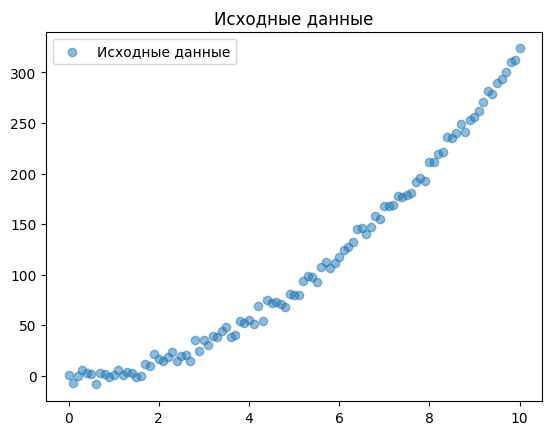



Коэффициенты регрессии: [109.16098795 944.91672397 227.16157162]




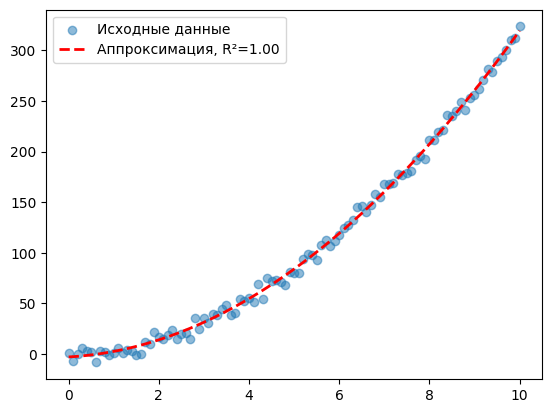

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
pandas2ri.activate()  # активация автоматического преобразования pandas в R

# Сгенерируем некоторые точки (шаг 0.1)
x = np.arange(0, 10.1, 0.1)
y = 3 * x**2 + 2*x + np.random.normal(scale=5, size=x.size)

# График исходных данных
plt.figure()
plt.scatter(x, y, alpha=0.5, label='Исходные данные')
plt.title('Исходные данные')
plt.legend()
plt.show()

# Создадим dataframe с нашими данными
import pandas as pd
df = pd.DataFrame({'x': x, 'y': y})

# Передаем данные в R с помощью pandas2ri
r_df = pandas2ri.py2rpy(df)

# Импортируем необходимые модули R
stats = importr('stats')

# Формула для полинома второго порядка
formula = robjects.Formula('y ~ poly(x, degree=2)')

# Применяем полиномиальную регрессию
poly_fit = stats.lm(formula, data=r_df)

coefficients = poly_fit.rx2('coefficients')
print("\n")
print("Коэффициенты регрессии:", coefficients)
print("\n")

# Получаем коэффициент детерминации R^2 через summary()
summary = stats.summary_lm(poly_fit)
r_squared = float(summary.rx2('r.squared')[0])

# Предсказываем значения в R
predicted_y_r = stats.predict(poly_fit, newdata=r_df)
predicted_y = np.array(predicted_y_r)

# Визуализируем результат и сохраняем
plt.figure()
plt.scatter(x, y, alpha=0.5, label='Исходные данные')
plt.plot(x, predicted_y, '--', color='red', linewidth=2, label=f'Аппроксимация, R²={r_squared:.2f}')
plt.legend()
plt.savefig('task5_regression.png', dpi=150, bbox_inches='tight')
plt.show()

--------------------------------------------------------